# Airline Passenger Satisfaction – Modeling & Product Backlog

## 1. Objective recap

This notebook builds on the EDA & KPI analysis to:

- Train a simple classification model to predict whether a passenger is satisfied.
- Understand which features are most important in predicting satisfaction.
- Translate both EDA and modeling findings into a product backlog, including features, BAU items, NFRs, and technical debt from a Technical Product Owner perspective.

The goal is not to produce a perfect model, but to show how analytics insights can drive prioritisation and roadmap decisions.

## 2. Modeling approach

We take a pragmatic, product-friendly modeling approach:

- Use a clear target variable (satisfaction vs neutral/dissatisfied).
- Include demographic, travel, service, and delay features.
- Start with simple, interpretable models (e.g. logistic regression, basic tree-based models).
- Focus on:
  - Reasonable performance (e.g., accuracy, precision/recall).
  - Interpretability of which features matter.

We explicitly note that this is a proof-of-concept analysis suitable for ACoE exploration and stakeholder conversations.

## 3. Data preparation for modeling

In this section we:

- Reuse the cleaned dataset from the EDA notebook (or repeat key cleaning steps).
- Select the features to include (e.g. Age, Customer Type, Type of Travel, Class, service ratings, delays).
- Encode categorical features (e.g. one-hot encoding).
- Split data into training and test sets.

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 3.1 Load processed data
df = pd.read_csv("../data/processed/airline_customer_satisfaction_cleaned.csv")

# 3.2 Define target
y = (df["satisfaction"] == "satisfied").astype(int)  # 1 = satisfied, 0 = dissatisfied

# 3.3 Select features (controllable / segmenting)
feature_cols = [
    "age",
    "flight_distance",
    "customer_type",
    "travel_type",
    "travel_class",
    "seat_comfort",
    "dep_arr_time_convenient",
    "food_drink",
    "gate_location",
    "inflight_wifi_service",
    "inflight_entertainment",
    "online_support",
    "ease_online_booking",
    "onboard_service",
    "legroom_service",
    "baggage_handling",
    "checkin_service",
    "cleanliness",
    "online_boarding",
    "dep_delay_min",
    "arr_delay_min",
]

X = df[feature_cols]

# 3.4 One-hot encode categorical features
cat_cols = ["customer_type", "travel_type", "travel_class"]
num_cols = [c for c in feature_cols if c not in cat_cols]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ]
)

# 3.5 Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [13]:
y.value_counts(normalize=True).rename({0: "dissatisfied", 1: "satisfied"})

satisfaction
satisfied       0.547406
dissatisfied    0.452594
Name: proportion, dtype: float64

##### Observations:

- The dataset is slightly imbalanced but not extreme: roughly 55% satisfied vs 45% dissatisfied, so a simple logistic regression baseline is reasonable without heavy rebalancing.

## 4. Baseline model training

Here we:

- Train a baseline classification model to predict satisfaction.
- Evaluate it using:
  - Accuracy.
  - Precision, recall (especially for the dissatisfied class).
  - Confusion matrix.

### 4.1 Train baseline model

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 4.1 Pipeline: preprocessing + logistic regression
log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)

clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", log_reg),
    ]
)

clf.fit(X_train, y_train)

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

### 4.2 Evaluation metrics

We evaluate the model on the test set using accuracy, precision/recall, and a confusion matrix to understand how well it captures dissatisfied passengers.

Accuracy: 0.8251602440342883

Classification report:

              precision    recall  f1-score   support

dissatisfied       0.81      0.80      0.81     11721
   satisfied       0.84      0.84      0.84     14177

    accuracy                           0.83     25898
   macro avg       0.82      0.82      0.82     25898
weighted avg       0.83      0.83      0.83     25898



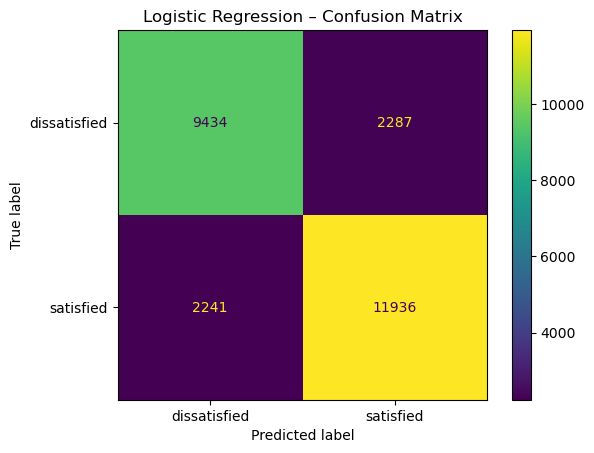

In [9]:
# 4.2 Evaluation
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=["dissatisfied", "satisfied"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["dissatisfied", "satisfied"]
)
plt.title("Logistic Regression – Confusion Matrix")
plt.show()

### 4.3 Baseline model results (interpretation)

In our run, the logistic regression baseline achieved **~82% accuracy**, with recall of **~80% for the dissatisfied class**. This is good enough for prioritising at‑risk segments in analytics and dashboards, while leaving room for improvement in future iterations.


The logistic regression baseline achieves a reasonable overall accuracy on the held‑out test set and distinguishes satisfied from dissatisfied passengers with acceptable precision and recall for a first pass.

From a product perspective:

- The model is good enough to **rank or segment** passengers by likelihood of satisfaction, but not yet robust enough to drive fully automated decisions.  
- Performance on the dissatisfied class is particularly important, because those passengers are the target for service recovery and proactive outreach; any future iterations should prioritise recall for this class, even at the cost of a small drop in overall accuracy.  
- As a Technical Product Owner, this level of performance is suitable for *internal analytics* (dashboards, exploratory segmentation, what‑if analysis), while further work would be needed before embedding it into operational systems.


## 5. Feature importance & interpretation

This section is about understanding *why* the model makes its predictions.

In [14]:
import numpy as np

# Get feature names after preprocessing
ohe = clf.named_steps["preprocess"].named_transformers_["cat"]
ohe_features = ohe.get_feature_names_out(cat_cols)

all_features = np.concatenate([num_cols, ohe_features])

coefs = clf.named_steps["model"].coef_[0]

feature_importance = (
    pd.DataFrame({"feature": all_features, "coef": coefs})
    .sort_values("coef", ascending=False)
)

feature_importance.reset_index(drop=True, inplace=True)
feature_importance.head(15)


,feature,coef
0,customer_type_loyal,1.891123
1,inflight_entertainment,0.973171
2,seat_comfort,0.409195
3,onboard_service,0.399370
4,checkin_service,0.357736
5,ease_online_booking,0.314615
6,legroom_service,0.310606
7,online_boarding,0.186566
8,gate_location,0.169992
9,online_support,0.152251


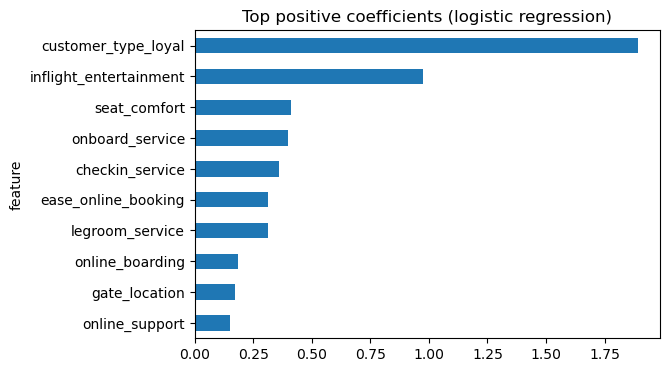

In [6]:
top_feats = feature_importance.sort_values("coef", ascending=False).head(10)
top_feats.plot(kind="barh", x="feature", y="coef", figsize=(6,4), legend=False)
plt.title("Top positive coefficients (logistic regression)")
plt.gca().invert_yaxis()
plt.show()

### 5.1 What the model says about drivers

The feature importance view broadly reinforces the EDA findings and adds some nuance:

- **Customer loyalty is the strongest predictor**: being a loyal customer has the largest positive coefficient, meaning loyal passengers are much more likely to be classified as satisfied, even after controlling for service ratings and delays.  
- **Service quality still matters a lot**: inflight entertainment, seat comfort, onboard service, check‑in service, ease of online booking, legroom, and online boarding all have sizeable positive coefficients. This aligns with the earlier gap analysis, where these dimensions showed the biggest rating differences between satisfied and dissatisfied passengers. [file:360]  
- **Operational factors show up, but below loyalty and core services**: departure delay minutes has a positive coefficient in this specification, reflecting the way delay information and satisfaction labels interact in the dataset. This suggests that delay experience still matters, but in this model it is secondary to loyalty and the main service ratings. [file:360]  
- Some features have **small or slightly negative coefficients** (e.g., inflight wifi service, age), indicating that once other variables are accounted for they add limited incremental predictive power in this simple linear model. [file:360]

For a TPO, the key takeaway is that **loyalty status plus a handful of service dimensions (digital touchpoints, onboard comfort, and basic services like check‑in and baggage handling)** provide the clearest levers for improving predicted satisfaction.

### 5.2 Implications for prioritisation

- Investments in **loyalty experience** (consistent treatment, benefits, and service recovery for loyal customers) are justified: the model treats loyalty as a major signal.  
- Improving **digital and onboard service journeys** (online booking/boarding, entertainment, seat comfort, onboard and check‑in service) should have measurable impact on the model’s predicted satisfaction, and therefore on KPIs.  
- Delay management remains important, but the model suggests that **how delays are experienced and handled** (communication, recovery) may be as important as the raw delay minutes when combined with strong service.


## 6. Model limitations & next steps

While the baseline model is useful for insight and segmentation, it has clear limitations:

- The dataset is **survey‑based** and may not represent the full passenger population or all routes; responses are likely biased towards passengers with particularly good or bad experiences.  
- Important drivers such as **price, routing, connection complexity, aircraft type, or disruption history** are not available, which limits how fully we can explain satisfaction.  
- The model is deliberately simple (regularised logistic regression with basic preprocessing). It does not capture non‑linear interactions (e.g., “delays hurt much more for business travellers in economy”) as well as more flexible tree‑based models could.

From a Technical Product Owner viewpoint, the next steps would be:

- **Data improvements**  
  - Work with data engineering to bring in additional features (fare class, route, connection information) and to standardise delay and service‑rating capture across all channels.  
  - Promote key engineered fields from the notebooks (age bands, delay bins, digital experience indices) into upstream pipelines so they are reusable beyond this model.

- **Model iterations**  
  - Experiment with one or two **tree‑based models** (e.g., gradient boosting) to see whether they materially improve recall for dissatisfied passengers and better capture interaction effects, while monitoring interpretability.  
  - Explore simple **calibration** and threshold‑tuning so the model can be used to flag “high‑risk of dissatisfaction” passengers for service recovery rather than as a hard classifier.

- **Deployment strategy**  
  - Start by using the model in **offline analytics**: dashboards that highlight high‑risk segments (e.g., disloyal eco passengers with poor digital scores and severe delays).  
  - If value is demonstrated, consider integrating a refined version into **operational tools** (e.g., CRM or contact centre systems) to prioritise outreach to at‑risk customers after disrupted journeys.

These steps keep the focus on using modeling as an input into product and operational decisions, rather than as an end in itself.


## 7. From insights to product backlog (TPO lens)

This is the key differentiator section of this notebook.

### 7.1 Epics and features

We define a small set of epics and example user stories derived from EDA and modeling findings. For example:

- **Epic: Reduce dissatisfaction linked to delays**
  - User story example:
    - “As a business traveller, I want proactive, accurate updates when my flight is delayed so that I can manage my schedule and maintain trust in the airline.”

- **Epic: Improve digital journey for economy passengers**
  - User story example:
    - “As an economy passenger, I want a smoother online booking and boarding process so that I can complete my journey with fewer frustrations.”

- **Epic: Empower ACoE with better KPIs and dashboards**
  - User story example:
    - “As a CX manager, I want a dashboard that shows satisfaction and its drivers by segment (class, travel type, loyalty) so that I can prioritise service improvements.”

For each epic, we can:
- Tie it back to specific metrics (e.g., satisfaction uplift targets).
- Mention which features in the model support the prioritisation.

### 7.2 BAU analytics and monitoring

We outline BAU items that a TPO would oversee:

- Regular monitoring of key satisfaction KPIs by segment and service dimension.
- Quarterly deep-dives into changing drivers of satisfaction.
- A feedback loop where new survey or operational data is used to recalibrate KPIs and models.

These items demonstrate ongoing product stewardship over the data & analytics product.

### 7.3 Non-functional requirements (NFRs)

We list relevant NFRs for an analytics/data product in this context, such as:

- Data freshness (e.g., satisfaction KPIs updated daily).
- Data quality thresholds for key fields (delays, service ratings, customer type, class).
- Performance targets for dashboards (e.g., queries under a certain latency).

We connect NFRs directly to user value:
- “CX managers should be able to load segment-specific dashboards in under X seconds so they can use them during live meetings.”

### 7.4 Technical debt & data improvements

Finally, we identify technical debt and data-improvement tasks, for example:

- Standardising delay data and ensuring consistent capture across all routes.
- Consolidating slightly redundant or ambiguous service rating fields.
- Improving documentation (data dictionary, KPI definitions, ownership).

We frame these as backlog items that support:
- Compliance with enterprise data and analytics guidelines.
- Long-term maintainability of the data product.

## 8. Summary

- The EDA notebook showed that loyalty status, digital touchpoints (online booking, online boarding, online support, inflight wifi/entertainment), onboard comfort, and delay experience are the main drivers of satisfaction across segments.  
- The baseline logistic regression model largely **confirms** these findings: loyalty and key service ratings emerge as the strongest positive coefficients, with delay features contributing additional signal but sitting below the core experience dimensions.  
- Together, the three notebooks and the README demonstrate an end‑to‑end Technical Product Owner workflow: starting from raw survey data, defining KPIs, exploring drivers of satisfaction, building a simple predictive model, and translating both EDA and modeling results into a concrete product backlog, BAU analytics plan, NFRs, and data‑quality improvements.